# Real Euclid images versus position-matched MER photometry

This notebook measures the actual public Euclid Q1 VIS/Y/J/H mosaics in **70 real-image scene regions, including 30 additional spatially separated patch IDs excluded from the existing train, validation and test splits** and compares each flux with its position-matched MER catalog reference. It includes three measurements on common sources and masks:

- The linked package’s actual upstream workflow: SEP blob detection/model selection on VIS, with Tractor’s profile ladder and archive GRID-PSFs, followed by its native forced-flux measurement in each band.
- JAISP’s mixture photometer using a raw-VIS image prior.
- The same mixture photometer using its frozen foundation prior.

Real VIS references use `flux_vis_sersic`; the extended-source MER NISP cross-check uses `flux_{y,j,h}_templfit` (the same reference choice made in the source notebook). These MER products are real pipeline catalog measurements, **not independent truth**. We therefore call the vertical axis measured-minus-MER offset. The model fits and MER fluxes are both in μJy before AB conversion.

The comparison uses the identical downloaded image cutouts, variance maps, pixel masks, archive PSF fields, and source list. Tractor runs the unmodified upstream SEP source selection and position refinement. The mixture measurements use Tractor’s refined positions as well. All 629 MER-matched sources are retained in the comparison table. The magnitude plot shows each source with positive fitted flux for that method; zero or negative fits remain in the table because AB magnitude offsets are undefined for them. The main plot includes all source-quality flags and edge positions, with the clean subset available in the summary.

The real image/PSF caches and local MER catalog are under `runs/real_mer/`. See the region manifests for archive tile IDs, image zero points and PSF paths.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'models/photometry/self_supervised').is_dir())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
OUT=ROOT/'models/photometry/self_supervised/runs/real_mer'


## Match real fluxes and make the plots

The local catalogs are matched by MER object ID after the original sky coordinates place MER sources onto each native image. This cell checks exact source/band/model coverage, keeps the archived MAGZERO conversion, and writes the per-source comparison, summaries and figures.

In [2]:
from models.photometry.self_supervised.real_mer_report import collect,summarize,make_plots
import os
os.chdir(ROOT)
matched=collect()
summary=summarize(matched)
figures=make_plots(matched)
print(f"Real MER sources: {matched.object_id.nunique()} | regions: {matched.region.nunique()} | source/band/method rows: {len(matched)}")
print('Total MER-matched sources per band and method:')
display(summary[summary.subset=='all'].pivot(index='band',columns='model',values='n_reference'))
print('Sources with positive fitted flux (plotted AB offsets):')
display(summary[summary.subset=='all'].pivot(index='band',columns='model',values='n'))
print('Median offset using all sources with positive fitted flux:')
display(summary[summary.subset=='all'].pivot(index='band',columns='model',values='median_delta_ab').round(3))
print('Clean-geometry subset for comparison:')
display(summary[summary.subset=='clean'].pivot(index='band',columns='model',values='n'))


Real MER sources: 629 | regions: 70 | source/band/method rows: 10064
Total MER-matched sources per band and method:
Sources with positive fitted flux (plotted AB offsets):
Median offset using all sources with positive fitted flux:
Clean-geometry subset for comparison:


/home/shemmati/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


model,foundation,image,tractor_jointsky,tractor_upstream
band,,,,
euclid_H,629,629,629,629
euclid_J,629,629,629,629
euclid_VIS,629,629,629,629
euclid_Y,629,629,629,629


model,foundation,image,tractor_jointsky,tractor_upstream
band,,,,
euclid_H,612,611,551,609
euclid_J,617,617,571,612
euclid_VIS,624,623,559,624
euclid_Y,614,614,553,609


model,foundation,image,tractor_jointsky,tractor_upstream
band,,,,
euclid_H,-0.001,-0.023,0.045,0.005
euclid_J,-0.002,-0.016,0.044,0.004
euclid_VIS,-0.052,-0.065,0.012,0.004
euclid_Y,0.000,-0.017,0.068,0.028


model,foundation,image,tractor_jointsky,tractor_upstream
band,,,,
euclid_H,309,309,284,307
euclid_J,314,314,292,310
euclid_VIS,318,318,291,318
euclid_Y,311,311,285,309


## Real-image magnitude offsets

The x-axis is the MER reference AB magnitude, `23.9 − 2.5 log10(flux_uJy)`. The y-axis is measured AB magnitude minus the MER reference magnitude. Faint points show each source; curves are running medians with the central 68% source distribution shaded. The main plot includes all matched sources and all quality flags. A zero or negative fitted flux has no AB offset; those sources stay in the CSV and their counts are shown in the notebook. No simulated pixel data or known injected fluxes enter these measurements.

## Inspect a problematic real-image cutout

The report selects the region with the largest median absolute VIS foundation offset (currently region 046). These are the actual 20-arcsec Euclid image cutouts in VIS, Y, J and H, with every MER source labeled by its row index. Marker color shows the foundation-minus-MER ΔAB for that band (color scale clipped at ±1.5 mag); circles pass the clean-geometry screen, squares fail it, and crosses have no valid positive-flux AB offset. The black image area is masked survey coverage. The next figure compares the observed VIS cutout with Tractor and foundation residual maps in pixel-noise units. Use the row index to look up source fluxes, neighbors and flags in `matched_real_photometry.csv` and `references.csv`.

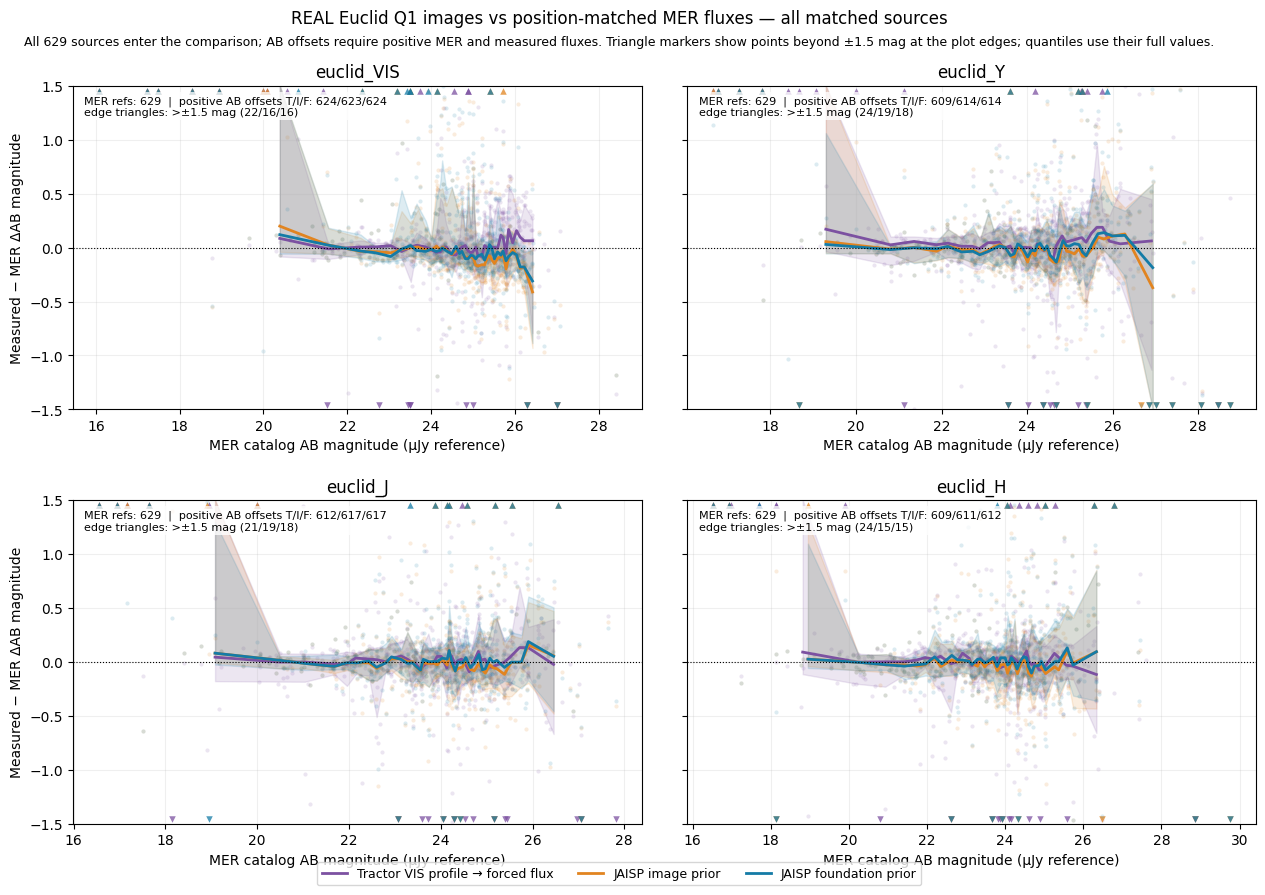

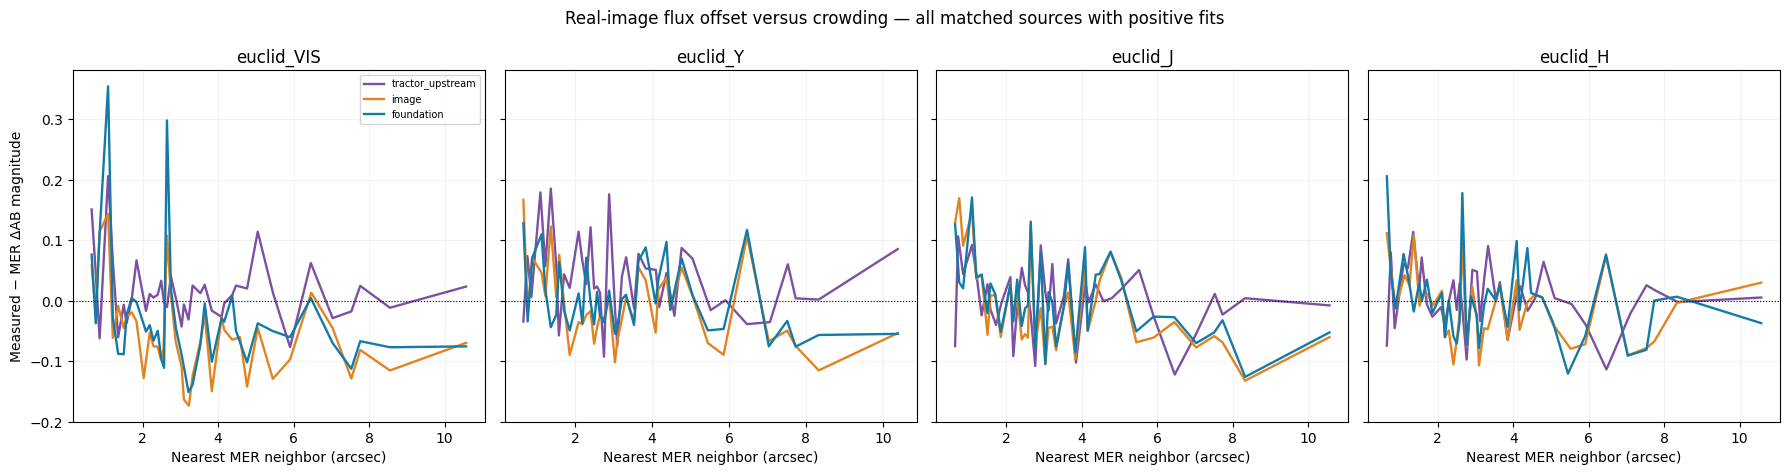

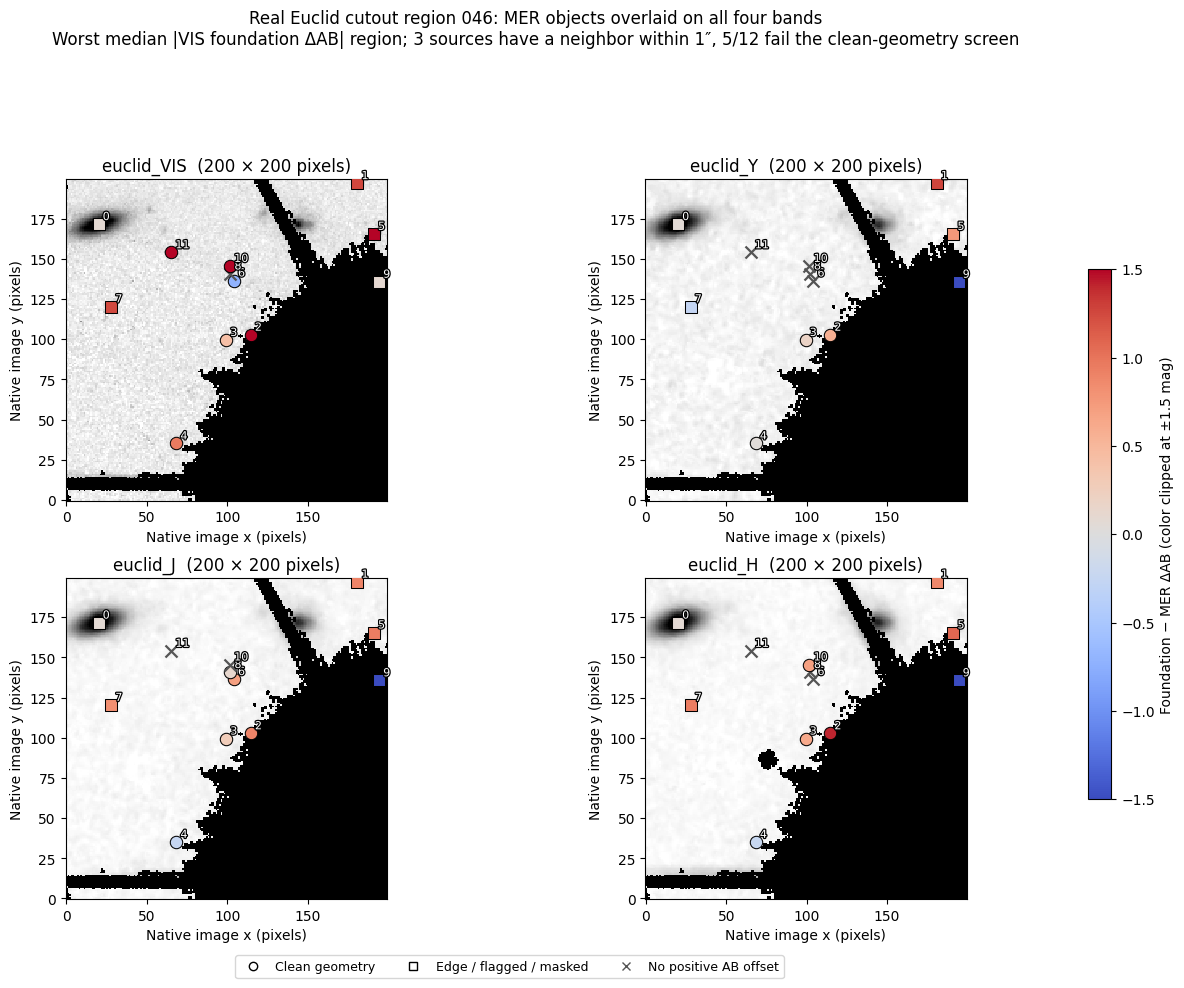

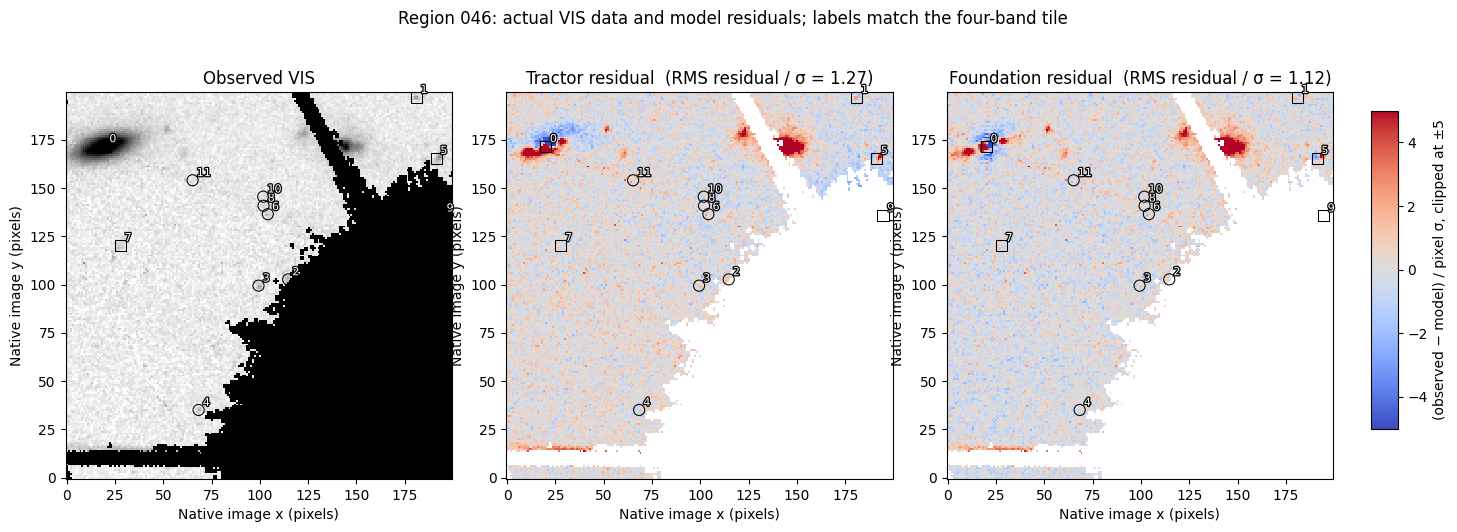

In [3]:
for f in figures:
    display(f);plt.close(f)

## Crowding and source diagnostics

The offset-versus-neighbor-distance plot also uses all matched sources with positive fitted flux. The summary retains clean, isolated and crowded subsets so you can compare those cuts against the full sample. A small MER residual does not establish unbiased flux, since MER fits the same survey products and has its own blend/profile choices.

For the detailed method definitions, per-region Tractor model-selection counts, cached image headers, variances, quality masks and spatial PSF stamps, inspect `runs/real_mer/region_*/`. PSF arrays and source pixels are kept for residual-image inspection.